# Least Squares Example: Polynomial Regression

Suppose we've been given the following 9 input/output data pairs:

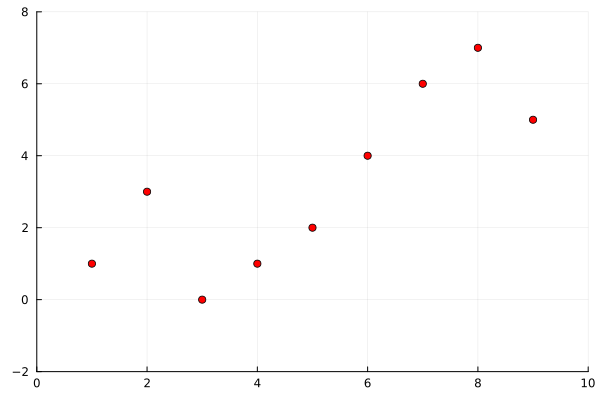

In [7]:
# define (x,y) coordinates of the points
x = [ 1, 2, 3, 4, 5, 6, 7, 8, 9 ]
y = [ 1, 3, 0, 1, 2, 4, 6, 7, 5 ]

# We can use the Plots package to graph these points

### NOTE: In the recordings, I used the "PyPlots" package. The most recent update
# of Julia makes Plots *much* easier to use, so I'm slowly switching everything 
# over to Plots. Syntax is mostly the same - see https://docs.juliaplots.org/stable/tutorial/
# for the overview. ###

using Plots
scatter(x,y,mc=:red, width=10,legend=false)
xlims!(0,10)
ylims!(-2,8)

These points look like they might fit a polynomial of degree 3 (highest order term is $x^3$). Let's try fitting a polynomial to these points:

In [8]:
# order of polynomial to use
k = 3

# fit using a function of the form f(x) = p x^k + q x^(k-1) + ... + rk x + s

# our matrix A will need to have m rows, where m is the number of data points
m = length(x)
# initialize A to be a matrix of zeros with m rows and k+1 columns
# (there will be coefficients on x^3, x^2, x^1, and x^0, so 4 columns)
A = zeros(m,k+1)

# now loop over each row and each column
# the ij'th entry of A will be x_i ^ (k+1 - j)
# e.g., row 1 column 1: x_1 ^ (4-1) = x_1^3
for i = 1:m
    for j = 1:k+1
        A[i,j] = x[i]^(k+1-j)
    end
end
display(A)

9×4 Matrix{Float64}:
   1.0   1.0  1.0  1.0
   8.0   4.0  2.0  1.0
  27.0   9.0  3.0  1.0
  64.0  16.0  4.0  1.0
 125.0  25.0  5.0  1.0
 216.0  36.0  6.0  1.0
 343.0  49.0  7.0  1.0
 512.0  64.0  8.0  1.0
 729.0  81.0  9.0  1.0

Let's call our variables/polynomial coefficients "u" to avoid notation confusion. Now our goal is to try to solve Au = y to find the values of u that best match our data.

We'll  solve our least squres problem in a few different ways. First, we'll solve it as an optimization problem where we minimize the 2-norm of Au - y:

In [9]:
# You may need to "Pkg.add" the Ipopt solver
# "Ipopt" = "Interior Point optimizer." It's primarily used for nonlinear optimization.

using JuMP, Ipopt

m = Model(Ipopt.Optimizer)

@variable(m, u[1:k+1])
@objective(m, Min, sum( (y - A*u).^2 ) )
set_silent(m)

optimize!(m)
uopt = value.(u)
println(uopt)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

[-0.06481481481482868, 1.0425685425687596, -4.083092833093806, 5.206349206350313]


Next, we'll solve it using the normal equations:

In [10]:
inv(A'*A)*(A'*y)

4-element Vector{Float64}:
 -0.06481481481481696
  1.042568542568557
 -4.0830928330929055
  5.206349206349262

Finally, we'll use the backslash operator:

In [11]:
A\y

4-element Vector{Float64}:
 -0.06481481481481523
  1.0425685425685498
 -4.083092833092868
  5.206349206349252

As you can see, we got the same answer using all three approaches! Now let's plot our data versus our polynomial to see how we did. We can also calculate the 2-norm of Au - y to find the magnitude of the "error" between our data and polynomial.

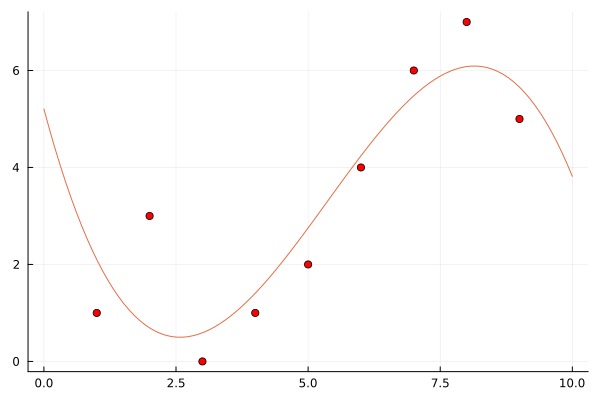

In [19]:
using Plots

# we'll graph 100 points along our polynomial between x=0 and x=10
npts = 100
x_poly = range(0,stop=10,length=npts)
# initialize the output vector with all zeros
y_poly = zeros(npts)

# calculate what each output should be using our polynomial
for j = 1:npts
    y_poly[j] = uopt[1] * x_poly[j]^3 + uopt[2] * x_poly[j]^2 + uopt[3] * x_poly[j] + uopt[4]
end

# graph the observed data against the point
scatter( x, y, mc=:red, width=10)
display(plot!( x_poly, y_poly, mc=:black, legend=false))
xlims!(0,10)
ylims!=(-2,8)
;

In [20]:
# total error ||Ax - y||
y_calc = zeros(9)
for j = 1:9
    y_calc[j] = uopt[1] * x[j]^3 + uopt[2] * x[j]^2 + uopt[3] * x[j] + uopt[4]
end

using LinearAlgebra
err = norm(y_calc - y)
println("Total 2-norm error: ", err)

Total 2-norm error: 3.0374050974194597
